In [7]:
import pandas as pd
import numpy as np
from os import listdir


In [8]:
import sklearn

In [9]:
# Ignore warnings
import warnings; warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.model_selection import LeaveOneGroupOut
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score
from sklearn import svm
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

#from skbold.preproc.confounds import ConfoundRegressor
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn import preprocessing
    
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,confusion_matrix, recall_score, precision_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer



# Import libraries
import os
import numpy as np
import pandas as pd


from sklearn.feature_selection import RFE
from sklearn.metrics import balanced_accuracy_score

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer
from sklearn.metrics import \
    confusion_matrix, \
    accuracy_score, \
    matthews_corrcoef, \
    precision_score, \
    recall_score, \
    f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut


import pymrmr

# Set the random generator seed
seed = 42

# Matplotlib settings
plt.style.use("classic")

# Seaborn settings
sns.set()
sns.set(font_scale=1.0)
sns.set_style({"font.family":"serif", "font.serif":["Times New Roman"]})

# Show seaborn settings
sns.axes_style()

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [10]:
# ------------------------------
# Define the classifier settings
# ------------------------------

model_params = {
    
    # General parameters
    "booster": "gbtree", 
    "silent": True, 
    "n_jobs": -1, 
    
    # Learning task parameters
    "objective": "binary:logistic",  # https://xgboost.readthedocs.io/en/latest/parameter.html
    "eval_metric": "error", 
    "seed": seed, 
    
    # Tree Booster parameters
    "n_estimators": 500, 
    "learning_rate": 0.20, 
    "gamma": 1.0, 
    "max_depth": 10, 
    "subsample": 1.0, 
    "colsample_bylevel": 1, 
    "colsample_bytree": 1.0, 
    "min_child_weight": 5
}

# ------------------------------------------
# Define the hyper-parameter tuning settings
# ------------------------------------------

param_grid = {
    "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.3], 
    "gamma": [0, 0.10, 0.15, 0.25, 0.5], 
    "max_depth": [6, 8, 10, 12, 15],  
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bylevel": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "min_child_weight": [0.5, 1.0, 3.0, 5.0, 7.0, 10.0], 
    "scale_pos_weight": [1, 3, 5, 6, 7, 9]  # https://machinelearningmastery.com/xgboost-for-imbalanced-classification/
#scale_pos_weight = total_negative_examples / total_positive_examples
}

search_settings = {
    "param_distributions": param_grid, 
    "scoring": "balanced_accuracy",  # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
    "n_jobs": -1, 
    "n_iter": 500, 
    "verbose": 1
}

In [11]:
# ---------------------------------
# Define the classification metrics
# ---------------------------------

def sensitivity_score(y_true, y_pred):
    return recall_score(y_true, y_pred)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

In [12]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression as lr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os

# For preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split

# For models
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# For evaluation
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import OneHotEncoder


In [13]:
colff= ['21_123angle_aft_MFCC_10',
 '40_87angle_aft_MFCC_10',
 '64_116angle_mid_Peak to peak distance',
 '113_121distance_mid_Median',
 '95_120distance_mid_Histogram mode',
 '95_121distance_mid_ECDF Percentile_0',
 '3_49angle_mid_Skewness',
 '65_100angle_eve_MFCC_10',
 '55_105angle_mor_Wavelet variance_12.5Hz',
 '43_131distance_aft_Median absolute deviation',
 '23_58angle_eve_LPCC_6',
 '104_105angle_aft_LPCC_6',
 '13_48angle_aft_Wavelet variance_3.12Hz',
 '16_32distance_aft_Interquartile range',
 '8_37distance_mid_MFCC_11',
 '40_62distance_eve_MFCC_5',
 '19_97distance_aft_MFCC_10',
 '92_96angle_eve_MFCC_9',
 '30_67angle_eve_MFCC_3',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '24_42angle_eve_Interquartile range',
 '92_118distance_mid_MFCC_7',
 '35_67distance_mid_Median absolute diff',
 '101_102distance_mid_MFCC_8',
 '5_7distance_aft_MFCC_5',
 '27_29distance_aft_Median absolute deviation',
 '54_117angle_eve_Peak to peak distance',
 '4_31distance_mid_Skewness',
 '111_130distance_mid_Interquartile range',
 '22_39angle_eve_Peak to peak distance',
 '22_60angle_eve_Peak to peak distance',
 '3_7distance_aft_MFCC_10',
 '7_49angle_aft_Spectral spread',
 '106_118distance_mid_Interquartile range',
 '22_68angle_mid_MFCC_0',
 '102_106angle_aft_LPCC_6',
 '112_129distance_eve_Wavelet variance_12.5Hz',
 '96_118angle_mid_Min',
 '44_123angle_mor_Median diff',
 '126_129angle_aft_Wavelet variance_2.78Hz',
 '23_58angle_aft_Human range energy',
 '19_119angle_mid_Median',
 '89_130angle_eve_Median diff',
 '50_106angle_aft_MFCC_1',
 '121_130distance_mid_Histogram mode',
 '30_59angle_mid_Spectral variation',
 '48_57distance_eve_Histogram mode',
 '22_113angle_aft_ECDF Percentile_1',
 '101_107angle_aft_LPCC_6',
 '33_69angle_aft_MFCC_7',
 '14_47angle_mid_Spectral entropy',
 '14_78angle_mor_Wavelet entropy',
 '90_123angle_mid_MFCC_4',
 '20_128angle_aft_Interquartile range',
 '4_9distance_aft_MFCC_5',
 '53_62angle_eve_MFCC_3',
 '2_97angle_eve_Peak to peak distance',
 '117_118angle_aft_Spectral spread',
 '43_91angle_aft_Variance',
 '64_124angle_aft_LPCC_2',
 '64_124angle_aft_LPCC_10',
 '129_130distance_aft_Kurtosis',
 '42_129distance_mor_Median diff',
 '30_61angle_eve_MFCC_3',
 '35_100angle_eve_Peak to peak distance',
 '5_52distance_eve_ECDF Percentile_1',
 '53_117angle_eve_MFCC_5',
 '109_130distance_mid_Histogram mode',
 '55_105angle_aft_ECDF Percentile_1',
 '65_99angle_mor_Spectral entropy',
 '115_124angle_mid_Root mean square',
 '15_76angle_eve_Peak to peak distance',
 '0_9distance_aft_MFCC_5',
 '74_107angle_eve_Max',
 '92_116angle_mid_MFCC_10',
 '98_114angle_eve_Spectral roll-on',
 '115_124distance_aft_Wavelet standard deviation_4.17Hz',
 '0_7angle_aft_MFCC_10',
 '67_127angle_aft_MFCC_0',
 '34_71angle_aft_MFCC_8',
 '65_124angle_aft_Wavelet variance_2.78Hz',
 '22_127angle_mor_MFCC_8',
 '14_81angle_eve_Peak to peak distance',
 '15_48angle_eve_Peak to peak distance',
 '55_119distance_aft_Median diff',
 '110_113angle_mid_Spectral decrease',
 '18_107distance_aft_MFCC_10',
 '48_61distance_mor_MFCC_0',
 '0_55angle_eve_Power bandwidth',
 '4_74angle_eve_MFCC_7',
 '73_118angle_aft_Wavelet variance_2.78Hz',
 '63_115angle_eve_MFCC_11',
 '78_82angle_mid_Spectral entropy',
 '35_114angle_aft_LPCC_6',
 '20_98distance_aft_MFCC_10',
 '97_128distance_eve_Variance',
 '15_113angle_eve_MFCC_0',
 '61_99angle_eve_MFCC_10',
 '44_74angle_mid_MFCC_9',
 '103_109angle_mid_MFCC_6',
 '121_128distance_mid_Median',
 '54_67distance_aft_Median frequency',
 '107_109angle_eve_Spectral roll-on',
 '4_130angle_eve_MFCC_0',
 '45_97angle_aft_MFCC_11',
 '72_86angle_eve_MFCC_9',
 '49_61distance_mor_MFCC_0',
 '14_82angle_mor_Mean absolute diff',
 '106_117distance_aft_Median absolute deviation',
 '108_132distance_aft_Mean absolute deviation',
 '14_132angle_eve_Peak to peak distance',
 '15_54angle_eve_Min',
 '107_117distance_mid_ECDF Percentile_1',
 '19_111angle_mor_MFCC_0',
 '63_99angle_mid_Peak to peak distance',
 '57_70distance_mor_MFCC_2',
 '0_114angle_eve_Max',
 '51_52distance_aft_MFCC_5',
 '5_11angle_eve_Peak to peak distance',
 '55_105angle_mor_Wavelet standard deviation_12.5Hz',
 '111_130distance_mid_Median absolute deviation',
 '17_55angle_mid_Peak to peak distance',
 '110_115angle_aft_Human range energy',
 '89_116angle_mid_MFCC_6',
 '21_124angle_aft_LPCC_1',
 '112_121distance_mid_Histogram mode',
 '17_20distance_aft_MFCC_4',
 '65_90angle_aft_Wavelet energy_8.33Hz',
 '70_91angle_aft_Max power spectrum',
 '60_61distance_eve_MFCC_5',
 '44_82distance_eve_Median diff',
 '35_116angle_eve_Peak to peak distance',
 '63_124angle_eve_Human range energy',
 '86_95angle_aft_MFCC_1']

In [14]:
import polars as pl
import csv


In [15]:
file_path = './dataset/ff/data_all_ff.csv'

In [12]:
# Specify the columns you want to read
columns_to_read = colff + ['diagnosis', 'patient', 'record']

In [13]:
 # Step 3: Use scan_csv and select to read specific columns
df = pl.scan_csv(file_path).select(columns_to_read).collect()


In [14]:
dataset = df.to_pandas()

In [15]:
subdata = pd.read_csv('./dataset/ff_cross/ff_0_.csv')
subdata2 =pd.read_csv('./dataset/ff_cross/ff_1_.csv')

In [16]:
flag = 0 
for i in range(0, 43):
    subdata = pd.read_csv('./dataset/ff_cross/ff_'+str(i)+'_.csv')
    if len(subdata)>1:
        if flag==0:
            subdata_all = subdata.loc[1:].copy()
            flag = 1
        else:
            subdata_all = pd.concat([subdata_all, subdata.loc[1:]])



In [17]:
del subdata_all['Unnamed: 0']
del subdata_all['type_data']
del subdata_all['subrecord']

In [18]:
subdata_all = subdata_all[columns_to_read]

In [19]:
dataset = pd.concat([dataset, subdata_all])

In [20]:
group = dataset['patient']

In [21]:
group = dataset['patient']
patients_pandas_encoded = pd.get_dummies(group, columns=['patient'], drop_first=False)


In [22]:
del dataset['patient']

In [23]:
dataset = dataset.fillna(dataset.mean())

In [24]:
y = dataset['diagnosis']

In [25]:
records  = dataset['record']

In [26]:
del dataset['record']

In [27]:
X = dataset.copy()

# Feature selection

In [28]:
import pymrmr

In [29]:
X = dataset.copy()

In [30]:
del X['diagnosis']

In [31]:
type_classification = 'binary'



#X = X.replace([np.nan, -np.inf, np.inf], 0)
ratio_scaler = (len(y) - np.sum(y))/np.sum(y)
#y = y.reshape((len(y), ))
X.insert(loc=0, column='class', value=y)
X_to_choose = X.copy()
#Discritize data
_, nr_col = np.shape(X)
for i in range(1, nr_col):
    discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
    X.iloc[:, i] = discretizer.fit_transform(X.iloc[:, i].values.reshape(-1,1))
    
col = pymrmr.mRMR(X, 'MIQ', 100)


In [32]:
col

['115_124angle_mid_Root mean square',
 '23_58angle_eve_LPCC_6',
 '14_82angle_mor_Mean absolute diff',
 '16_32distance_aft_Interquartile range',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '103_109angle_mid_MFCC_6',
 '15_113angle_eve_MFCC_0',
 '107_117distance_mid_ECDF Percentile_1',
 '107_109angle_eve_Spectral roll-on',
 '14_78angle_mor_Wavelet entropy',
 '106_118distance_mid_Interquartile range',
 '92_116angle_mid_MFCC_10',
 '42_129distance_mor_Median diff',
 '112_129distance_eve_Wavelet variance_12.5Hz',
 '55_105angle_mor_Wavelet variance_12.5Hz',
 '19_119angle_mid_Median',
 '72_86angle_eve_MFCC_9',
 '14_47angle_mid_Spectral entropy',
 '98_114angle_eve_Spectral roll-on',
 '44_82distance_eve_Median diff',
 '61_99angle_eve_MFCC_10',
 '20_98distance_aft_MFCC_10',
 '19_111angle_mor_MFCC_0',
 '63_115angle_eve_MFCC_11',
 '44_74angle_mid_MFCC_9',
 '111_130distance_mid_Interquartile range',
 '35_100angle_eve_Peak to peak distance',
 '5_7distance_aft_MFCC_5',
 '89_116angle_mid_MFCC_6',
 '3

In [33]:
colff100 = ['115_124angle_mid_Root mean square',
 '23_58angle_eve_LPCC_6',
 '14_82angle_mor_Mean absolute diff',
 '16_32distance_aft_Interquartile range',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '103_109angle_mid_MFCC_6',
 '15_113angle_eve_MFCC_0',
 '107_117distance_mid_ECDF Percentile_1',
 '107_109angle_eve_Spectral roll-on',
 '14_78angle_mor_Wavelet entropy',
 '106_118distance_mid_Interquartile range',
 '92_116angle_mid_MFCC_10',
 '42_129distance_mor_Median diff',
 '112_129distance_eve_Wavelet variance_12.5Hz',
 '55_105angle_mor_Wavelet variance_12.5Hz',
 '19_119angle_mid_Median',
 '72_86angle_eve_MFCC_9',
 '14_47angle_mid_Spectral entropy',
 '98_114angle_eve_Spectral roll-on',
 '44_82distance_eve_Median diff',
 '61_99angle_eve_MFCC_10',
 '20_98distance_aft_MFCC_10',
 '19_111angle_mor_MFCC_0',
 '63_115angle_eve_MFCC_11',
 '44_74angle_mid_MFCC_9',
 '111_130distance_mid_Interquartile range',
 '35_100angle_eve_Peak to peak distance',
 '5_7distance_aft_MFCC_5',
 '89_116angle_mid_MFCC_6',
 '30_67angle_eve_MFCC_3',
 '63_124angle_eve_Human range energy',
 '95_120distance_mid_Histogram mode',
 '55_105angle_mor_Wavelet standard deviation_12.5Hz',
 '92_118distance_mid_MFCC_7',
 '24_42angle_eve_Interquartile range',
 '35_67distance_mid_Median absolute diff',
 '4_31distance_mid_Skewness',
 '4_130angle_eve_MFCC_0',
 '0_55angle_eve_Power bandwidth',
 '111_130distance_mid_Median absolute deviation',
 '3_49angle_mid_Skewness',
 '4_74angle_eve_MFCC_7',
 '117_118angle_aft_Spectral spread',
 '22_39angle_eve_Peak to peak distance',
 '53_117angle_eve_MFCC_5',
 '22_68angle_mid_MFCC_0',
 '0_9distance_aft_MFCC_5',
 '78_82angle_mid_Spectral entropy',
 '95_121distance_mid_ECDF Percentile_0',
 '92_96angle_eve_MFCC_9',
 '8_37distance_mid_MFCC_11',
 '35_116angle_eve_Peak to peak distance',
 '57_70distance_mor_MFCC_2',
 '22_113angle_aft_ECDF Percentile_1',
 '7_49angle_aft_Spectral spread',
 '106_117distance_aft_Median absolute deviation',
 '13_48angle_aft_Wavelet variance_3.12Hz',
 '60_61distance_eve_MFCC_5',
 '15_48angle_eve_Peak to peak distance',
 '44_123angle_mor_Median diff',
 '23_58angle_aft_Human range energy',
 '22_60angle_eve_Peak to peak distance',
 '33_69angle_aft_MFCC_7',
 '30_61angle_eve_MFCC_3',
 '4_9distance_aft_MFCC_5',
 '109_130distance_mid_Histogram mode',
 '53_62angle_eve_MFCC_3',
 '64_124angle_aft_LPCC_10',
 '5_11angle_eve_Peak to peak distance',
 '54_67distance_aft_Median frequency',
 '34_71angle_aft_MFCC_8',
 '35_114angle_aft_LPCC_6',
 '54_117angle_eve_Peak to peak distance',
 '121_128distance_mid_Median',
 '73_118angle_aft_Wavelet variance_2.78Hz',
 '14_81angle_eve_Peak to peak distance',
 '5_52distance_eve_ECDF Percentile_1',
 '64_124angle_aft_LPCC_2',
 '15_76angle_eve_Peak to peak distance',
 '19_97distance_aft_MFCC_10',
 '65_124angle_aft_Wavelet variance_2.78Hz',
 '90_123angle_mid_MFCC_4',
 '55_119distance_aft_Median diff',
 '65_100angle_eve_MFCC_10',
 '65_90angle_aft_Wavelet energy_8.33Hz',
 '14_132angle_eve_Peak to peak distance',
 '0_7angle_aft_MFCC_10',
 '96_118angle_mid_Min',
 '18_107distance_aft_MFCC_10',
 '51_52distance_aft_MFCC_5',
 '65_99angle_mor_Spectral entropy',
 '40_87angle_aft_MFCC_10',
 '126_129angle_aft_Wavelet variance_2.78Hz',
 '40_62distance_eve_MFCC_5',
 '86_95angle_aft_MFCC_1',
 '115_124distance_aft_Wavelet standard deviation_4.17Hz',
 '67_127angle_aft_MFCC_0',
 '101_107angle_aft_LPCC_6',
 '45_97angle_aft_MFCC_11',
 '121_130distance_mid_Histogram mode']

In [34]:
colf100 = col

In [35]:
ff_features = dataset[colff100]

# Read AU data

In [36]:
dataset = pd.read_csv('AU_features.csv')

In [37]:
del dataset['Unnamed: 0']
del dataset['index']

In [38]:
subdata_all = pd.concat([subdata, subdata2])
flag = 0 
for i in range(0, 43):
    subdata = pd.read_csv('.\dataset\AU_cross\AU_'+str(i)+'_.csv')
    if len(subdata)>1:
        if flag==0:
            subdata_all = subdata.loc[1:].copy()
            flag = 1
        else:
            subdata_all = pd.concat([subdata_all, subdata.loc[1:]])



In [39]:
del subdata_all['Unnamed: 0']
del subdata_all['type_data']
del subdata_all['subrecord']

In [40]:
dataset = pd.concat([dataset, subdata_all])

In [41]:
group = dataset['patient']

In [42]:
group = dataset['patient']
patients_pandas_encoded = pd.get_dummies(group, columns=['patient'], drop_first=False)


In [43]:
del dataset['patient']

In [44]:
dataset = dataset.fillna(dataset.mean())

In [45]:
y = dataset['diagnosis']

In [46]:
records  = dataset['record']

In [47]:
del dataset['record']

In [48]:
X = dataset.copy()

In [49]:
from pyHSICLasso import HSICLasso


In [50]:
del X['diagnosis']

In [51]:
del X['timestamp_start']
del X['timestamp_end']

In [52]:
#Initialize HSICLasso
hsic_lasso = HSICLasso()

# Load data
hsic_lasso.input(np.array(X), np.array(y), featname=X.columns)

True

In [53]:
hsic_lasso.classification(100)


Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


True

In [54]:
valuable_features_list = hsic_lasso.get_features()

In [55]:
colAU =  valuable_features_list

In [56]:
ff_features

,115_124angle_mid_Root mean square,23_58angle_eve_LPCC_6,14_82angle_mor_Mean absolute diff,16_32distance_aft_Interquartile range,89_99distance_mid_Wavelet variance_4.17Hz,103_109angle_mid_MFCC_6,15_113angle_eve_MFCC_0,107_117distance_mid_ECDF Percentile_1,107_109angle_eve_Spectral roll-on,14_78angle_mor_Wavelet entropy,...,65_99angle_mor_Spectral entropy,40_87angle_aft_MFCC_10,126_129angle_aft_Wavelet variance_2.78Hz,40_62distance_eve_MFCC_5,86_95angle_aft_MFCC_1,115_124distance_aft_Wavelet standard deviation_4.17Hz,67_127angle_aft_MFCC_0,101_107angle_aft_LPCC_6,45_97angle_aft_MFCC_11,121_130distance_mid_Histogram mode
0,0.799061,0.547888,0.140407,0.248338,0.001430,-32.270011,-8.506768,0.095242,0.133359,2.112047,...,0.819604,7.504664,4.053780,48.204722,-3.796997,0.025407,-20.846626,0.308425,26.413509,1.083121
1,0.805598,0.330272,0.206613,0.462673,0.000817,60.100474,-9.942865,0.094939,0.221566,2.134689,...,0.749516,56.955214,2.689024,-52.262840,2.275717,0.028937,-6.954738,0.374058,11.691812,1.123080
2,0.877206,0.355458,0.493341,0.150280,0.001581,0.964868,-18.733969,0.128673,0.315457,2.171846,...,0.807840,6.167841,8.257454,-9.441274,-21.500375,0.036353,-8.073340,0.304450,20.029895,1.207921
3,0.911890,0.402899,0.382914,0.258733,0.001716,26.350711,-12.901433,0.092525,0.000000,2.108104,...,0.750926,7.579477,7.362769,-38.945993,-56.053962,0.026002,-4.268017,0.535053,21.107155,1.189514
4,0.899741,0.045994,0.592048,0.238226,0.003014,45.764440,-23.261897,0.130291,0.444444,2.153781,...,0.804968,66.351058,4.474627,4.304561,-28.680302,0.029532,-26.980750,0.212446,59.323204,1.315989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.935580,0.496057,0.382914,0.246238,45.165079,11.515237,-3.808209,12.165525,0.802139,2.108104,...,0.750926,25.116756,4.906478,20.669608,-15.271290,0.031283,-13.950880,0.363771,20.533976,184.665488
3,0.807748,0.345896,0.382914,0.246238,206.856706,54.255723,-10.812835,36.345564,0.151223,2.108104,...,0.750926,25.116756,4.906478,6.959300,-15.271290,0.031283,-13.950880,0.363771,20.533976,229.551716
4,0.935580,0.603153,0.024631,0.246238,45.165079,11.515237,-4.169357,12.165525,0.152905,1.978126,...,0.820427,25.116756,4.906478,36.668726,-15.271290,0.031283,-13.950880,0.363771,20.533976,184.665488
5,0.946498,0.307000,0.382914,0.246238,44.360868,28.522029,-1.932140,16.344394,0.000000,2.108104,...,0.750926,25.116756,4.906478,3.078549,-15.271290,0.031283,-13.950880,0.363771,20.533976,179.933043


In [57]:
AU_features = dataset[colAU]

In [58]:
AU_features

,AU06_eve_LPCC_3,AU06_aft_LPCC_8,AU12_aft_ECDF Percentile_0,AU06_eve_SB_TransitionMatrix_3ac_sumdiagcov,AU04_eve_Wavelet variance_25.0Hz,AU04_aft_ECDF Percentile_1,AU17_mor_Mean absolute diff,AU24_eve_FC_LocalSimple_mean1_tauresrat,AU04_aft_Spectral kurtosis,AU23_mor_MFCC_2,...,AU10_aft_Spectral decrease,AU10_aft_Interquartile range,AU04_aft_Wavelet variance_6.25Hz,AU10_aft_ECDF Percentile_0,AU14_aft_MFCC_9,AU04_aft_Skewness,AU14_aft_Histogram mode,AU06_aft_ECDF Percentile_0,AU06_aft_LPCC_4,AU06_eve_LPCC_9
0,0.467778,0.357625,0.019837,0.005208,0.003817,0.013362,0.198662,0.023810,1.776869,-11.974438,...,-0.134991,0.048976,0.043134,1.856966e-05,75.701847,3.568308,0.050000,0.000372,0.357625,0.467778
1,0.321457,0.336955,0.000243,0.003750,0.038149,0.099797,0.182858,0.071429,1.909916,-8.599952,...,-0.117507,0.006106,0.083426,8.108293e-07,95.029416,2.101538,0.050000,0.000013,0.336955,0.321457
2,0.278050,0.370153,0.006894,0.083333,0.018921,0.108932,0.192040,0.013514,1.969486,-0.015893,...,-0.204177,0.006397,0.036079,4.336589e-05,110.342905,2.179159,0.949877,0.000064,0.370153,0.278050
3,0.421375,0.272728,0.026583,0.018229,0.014970,0.005352,0.192040,0.005556,1.687982,-0.015893,...,-0.170646,0.021142,0.000622,4.329745e-04,102.960006,7.995482,0.949953,0.000332,0.272728,0.421375
4,0.141733,0.239838,0.000402,0.004115,0.081924,0.210585,0.254536,0.166667,1.922836,21.008126,...,-0.166256,0.018430,0.122083,1.607636e-06,85.126379,1.938969,0.050000,0.000502,0.239838,0.141733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.701992,0.375770,0.051331,0.020576,0.043238,0.418947,0.075692,0.066667,1.993275,-8.927264,...,-0.464018,0.265787,0.124736,2.310617e-02,72.844196,2.344530,0.216404,0.100555,0.375770,0.701992
3,0.411001,0.444925,0.002207,0.030196,0.038438,0.043852,0.192040,0.227686,1.711978,-0.015893,...,-0.701109,0.134482,0.009349,1.941423e-02,72.917963,3.595074,0.946697,0.028348,0.444925,0.411001
4,0.598534,0.293735,0.022497,0.074074,0.027220,0.106263,0.075692,0.035714,1.553778,-8.927264,...,-0.468527,0.070988,0.011957,1.153671e-03,276.266167,2.260984,0.048886,0.006348,0.293735,0.598534
5,0.314630,0.375770,0.051331,0.016296,0.007303,0.418947,0.192040,0.500000,1.993275,-0.015893,...,-0.464018,0.265787,0.124736,2.310617e-02,72.844196,2.344530,0.216404,0.100555,0.375770,0.314630


# Read Euler data

In [59]:
dataset = pd.read_csv('euler_features.csv')

In [60]:
del dataset['Unnamed: 0']
del dataset['index']
del dataset['level_0']
del dataset['timestamp_start']
del dataset['timestamp_end']

In [61]:
flag = 0 
for i in range(0, 43):
    subdata = pd.read_csv('.\dataset\euler_cross\eul_'+str(i)+'_.csv')
    if len(subdata)>1:
        if flag==0:
            subdata_all = subdata.loc[1:].copy()
            flag = 1
        else:
            subdata_all = pd.concat([subdata_all, subdata.loc[1:]])



In [62]:
del subdata_all['Unnamed: 0']
del subdata_all['type_data']
del subdata_all['subrecord']

In [63]:
dataset = pd.concat([dataset, subdata_all])

In [64]:
subdata_all

,patient,record,diagnosis,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,...,Z_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_eve_SP_Summaries_welch_rect_centroid,Z_eve_FC_LocalSimple_mean3_stderr,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent,X_eve_rsd,Y_eve_rsd,Z_eve_rsd
1,P08,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,1.570796,1.275967,0.287682,0.058892,0.287682,87.722762,516.253163,-15.534977
2,P08,0,0,2600.470176,1.703505,2.0,18574.786972,0.062275,3.0,12.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
3,P08,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,P08,0,0,2600.470176,1.703505,2.0,18574.786972,0.062275,3.0,12.0,...,0.000000,0.000000,1.570796,1.275967,0.287682,0.058892,0.287682,87.722762,516.253163,-15.534977
5,P08,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.133333,0.800000,0.098175,0.662341,0.640145,0.372869,0.618174,53.749888,-244.113980,-46.387010
3,P38,42,0,36251.549716,26.396818,7.0,18035.596874,1.024986,40.0,161.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.127660,0.829787,0.042951,0.639221,0.495891,0.394368,0.538228,53.596463,-154.809423,-47.504810
5,P38,42,0,89778.428991,47.384176,9.0,33374.880666,1.347406,54.0,216.0,...,0.130435,0.826087,0.012272,0.358083,0.721151,0.482126,0.499161,34.958433,-70.161978,-346.662099


In [65]:
dataset

,patient,record,diagnosis,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,...,Z_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_eve_SP_Summaries_welch_rect_centroid,Z_eve_FC_LocalSimple_mean3_stderr,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent,X_eve_rsd,Y_eve_rsd,Z_eve_rsd
0,P08,0,0,23855.220164,17.340800,16.0,11580.203963,0.936651,41.0,165.0,...,0.183673,0.877551,0.038350,0.556470,1.240145,1.414059,1.101619,-137.406912,247.810229,-84.170855
1,P08,1,0,232834.486420,239.885354,42.0,6007.081693,21.592224,775.0,3101.0,...,0.437500,0.875000,0.104311,0.664134,1.110772,1.153594,1.206691,-246.703278,-917.852063,-147.429543
2,P10,2,1,47256.775336,54.145724,63.0,4535.199168,6.523586,208.0,834.0,...,0.125000,0.854167,0.193282,0.768328,0.829204,1.076619,1.013430,114.967050,-107.494007,-224.427014
3,P10,3,0,180776.973773,129.773994,65.0,14002.863964,7.335980,258.0,1033.0,...,0.224490,0.122449,0.138058,0.682936,0.659745,0.789076,0.931019,65.528455,-348.921557,-328.457878
4,P12,4,1,45579.869508,24.120677,8.0,30386.579672,0.962864,30.0,120.0,...,0.860465,0.139535,0.613592,0.924430,0.938069,0.806088,0.934574,72.352631,177.627123,159.713801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.133333,0.800000,0.098175,0.662341,0.640145,0.372869,0.618174,53.749888,-244.113980,-46.387010
3,P38,42,0,36251.549716,26.396818,7.0,18035.596874,1.024986,40.0,161.0,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
4,P38,42,0,2758.535817,1.653038,2.0,22987.798476,0.039375,2.0,10.0,...,0.127660,0.829787,0.042951,0.639221,0.495891,0.394368,0.538228,53.596463,-154.809423,-47.504810
5,P38,42,0,89778.428991,47.384176,9.0,33374.880666,1.347406,54.0,216.0,...,0.130435,0.826087,0.012272,0.358083,0.721151,0.482126,0.499161,34.958433,-70.161978,-346.662099


In [66]:
del dataset['patient']

In [67]:
dataset = dataset.fillna(dataset.mean())

In [68]:
y = dataset['diagnosis']

In [69]:
records  = dataset['record']

In [70]:
del dataset['record']

In [71]:
X = dataset.copy()

In [72]:
del X['diagnosis']


In [73]:
from pyHSICLasso import HSICLasso



In [74]:
#Initialize HSICLasso
hsic_lasso = HSICLasso()

# Load data
hsic_lasso.input(np.array(X), np.array(y), featname=X.columns)

True

In [75]:
hsic_lasso.classification(100)


Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


True

In [76]:
valuable_features_list = hsic_lasso.get_features()

In [77]:
coleul=  valuable_features_list

In [78]:
coleul = ['Z_aft_LPCC_7',
 'Y_eve_Median absolute diff',
 'Y_mid_Entropy',
 'Y_aft_Kurtosis',
 'Y_mor_rsd',
 'Z_aft_Spectral roll-on',
 'Z_aft_Human range energy',
 'Y_mid_Median absolute diff',
 'Y_aft_Interquartile range',
 'Z_eve_LPCC_0',
 'Y_mor_Median diff',
 'Y_eve_app_ent',
 'Y_eve_MD_hrv_classic_pnn40',
 'Z_mor_Wavelet entropy',
 'X_aft_FC_LocalSimple_mean1_tauresrat',
 'X_mor_Median absolute diff',
 'X_eve_Median absolute diff',
 'Y_mor_MFCC_6',
 'Y_aft_MFCC_2',
 'Z_aft_MFCC_9',
 'Z_aft_LPCC_5']


In [81]:
features_eul = dataset[coleul]

# Read the probability features

In [114]:
dataset = pd.read_csv('prob_eye_features.csv')

In [115]:
del dataset['Unnamed: 0']
del dataset['index']

In [116]:
dataset

,patient,record,diagnosis,timestamp_start,timestamp_end,lefteye_mid_Absolute energy,lefteye_mid_Area under the curve,lefteye_mid_Autocorrelation,lefteye_mid_Average power,lefteye_mid_Centroid,...,smiling_eve_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,smiling_eve_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,smiling_eve_SP_Summaries_welch_rect_centroid,smiling_eve_FC_LocalSimple_mean3_stderr,lefteye_eve_app_ent,righteye_eve_app_ent,smiling_eve_app_ent,lefteye_eve_rsd,righteye_eve_rsd,smiling_eve_rsd
0,P08,0,0,1.658354e+09,1.659996e+09,159.815202,1.754196,1.0,77.580195,1.084595,...,0.142857,0.775510,0.133456,0.731912,1.109208,1.273205,0.903131,31.248418,34.398221,161.223253
1,P08,1,0,1.659996e+09,1.661206e+09,2994.914034,32.251584,3.0,77.608552,19.458168,...,0.291667,0.145833,0.527689,0.941336,0.950498,1.165241,0.939005,30.496000,44.894973,156.000227
2,P10,2,1,1.658354e+09,1.659996e+09,934.998350,9.668103,1.0,89.817325,5.051412,...,0.333333,0.166667,0.285320,0.769152,0.649302,1.101207,0.211475,29.254278,47.014199,308.947966
3,P10,3,0,1.659996e+09,1.662070e+09,796.366897,9.202542,2.0,62.119103,6.491560,...,0.163265,0.877551,0.061359,0.511171,0.966557,1.240839,0.324205,44.624507,58.077534,246.734071
4,P12,4,1,1.658441e+09,1.659996e+09,47.911319,0.690634,1.0,31.940879,0.887026,...,0.790698,0.860465,0.662680,0.998367,0.938760,0.973181,0.404289,44.966219,47.288089,233.670461
5,P12,5,1,1.659996e+09,1.661206e+09,56.150528,0.624009,1.0,66.845867,0.465824,...,0.857143,0.738095,0.490874,0.878668,0.843667,0.936040,0.614584,29.475036,30.276012,185.631759
6,P13,6,0,1.658700e+09,1.659996e+09,3223.834261,32.655868,1.0,95.238826,16.860041,...,0.244898,0.857143,0.131155,0.653258,0.362176,0.705464,0.296124,16.339966,20.764821,292.398782
7,P13,7,0,1.659996e+09,1.661206e+09,239.778514,2.417260,1.0,96.296592,1.257414,...,0.853659,0.853659,0.392699,0.868253,0.255308,0.380562,0.414977,19.979949,15.211448,184.687507
8,P14,8,0,1.658700e+09,1.659910e+09,125.931396,1.407684,3.0,66.279682,1.000918,...,0.306122,0.877551,0.319068,0.859923,1.101882,0.904987,1.084499,42.789612,34.070540,137.389819
9,P15,9,0,1.658786e+09,1.660082e+09,NaN,NaN,NaN,NaN,NaN,...,0.326531,0.877551,0.161068,0.711376,1.208809,1.456139,0.330840,46.953204,49.437349,286.834391


In [117]:
del dataset['timestamp_start']
del dataset['timestamp_end']

In [118]:
subdata_all = pd.concat([subdata, subdata2])
flag = 0 
for i in range(0, 43):
    subdata = pd.read_csv('.\dataset\prob_cross\prob_'+str(i)+'_.csv')
    if len(subdata)>1:
        if flag==0:
            subdata_all = subdata.loc[1:].copy()
            flag = 1
        else:
            subdata_all = pd.concat([subdata_all, subdata.loc[1:]])



In [119]:
del subdata_all['Unnamed: 0']
del subdata_all['type_data']
del subdata_all['subrecord']

In [120]:
dataset = pd.concat([dataset, subdata_all])

In [121]:
del dataset['patient']

In [122]:
dataset = dataset.fillna(dataset.mean())

In [123]:
y = dataset['diagnosis']

In [124]:
records  = dataset['record']


In [125]:
del dataset['record']

In [126]:
X = dataset.copy()

In [127]:
del X['diagnosis']

In [128]:
#Initialize HSICLasso
hsic_lasso = HSICLasso()

# Load data
hsic_lasso.input(np.array(X), np.array(y), featname=X.columns)

True

In [129]:
hsic_lasso.classification(100)


Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


True

In [134]:
valuable_features_list = hsic_lasso.get_features()

In [135]:
colprob = valuable_features_list

In [136]:
prob_features = dataset[colprob]

In [140]:
import pymrmr

# Find the most important features for all modalities

In [141]:
dataset_mod = pd.concat([ff_features, AU_features, prob_features, features_eul], axis=1)

In [142]:
X = dataset_mod

In [143]:
type_classification = 'binary'



#X = X.replace([np.nan, -np.inf, np.inf], 0)
ratio_scaler = (len(y) - np.sum(y))/np.sum(y)
#y = y.reshape((len(y), ))
X.insert(loc=0, column='class', value=y)
X_to_choose = X.copy()
#Discritize data
_, nr_col = np.shape(X)
for i in range(1, nr_col):
    discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
    X.iloc[:, i] = discretizer.fit_transform(X.iloc[:, i].values.reshape(-1,1))
    
col = pymrmr.mRMR(X, 'MIQ', 50)


In [16]:
col = ['115_124angle_mid_Root mean square',
 'lefteye_mor_Mean diff',
 '23_58angle_eve_LPCC_6',
 '16_32distance_aft_Interquartile range',
 'AU24_eve_Spectral centroid',
 '14_82angle_mor_Mean absolute diff',
 '106_118distance_mid_Interquartile range',
 'smiling_eve_Interquartile range',
 'Z_aft_Spectral roll-on',
 'X_mor_Median absolute diff',
 'Y_aft_Interquartile range',
 'Z_aft_MFCC_9',
 'smiling_mor_MFCC_6',
 '107_109angle_eve_Spectral roll-on',
 '103_109angle_mid_MFCC_6',
 'Y_aft_Kurtosis',
 '107_117distance_mid_ECDF Percentile_1',
 'righteye_eve_Wavelet variance_2.78Hz',
 '15_113angle_eve_MFCC_0',
 'Z_aft_Human range energy',
 'AU06_eve_LPCC_10',
 'AU17_mor_Mean absolute diff',
 'Y_eve_MD_hrv_classic_pnn40',
 'AU07_aft_MFCC_3',
 '112_129distance_eve_Wavelet variance_12.5Hz',
 '14_78angle_mor_Wavelet entropy',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '92_116angle_mid_MFCC_10',
 'AU04_aft_ECDF Percentile_1',
 '19_119angle_mid_Median',
 'Z_eve_LPCC_0',
 '55_105angle_mor_Wavelet variance_12.5Hz',
 'AU07_eve_Wavelet variance_25.0Hz',
 'lefteye_mid_DN_OutlierInclude_n_001_mdrmd',
 'smiling_aft_Mean absolute diff',
 '20_98distance_aft_MFCC_10',
 'AU24_eve_SP_Summaries_welch_rect_centroid',
 '72_86angle_eve_MFCC_9',
 'lefteye_mid_Wavelet variance_25.0Hz',
 'lefteye_mor_MFCC_11',
 'AU14_aft_Spectral spread',
 'Y_mid_Median absolute diff',
 'Z_mor_Wavelet entropy',
 'smiling_eve_Mean absolute diff',
 '63_115angle_eve_MFCC_11',
 'AU06_mid_SP_Summaries_welch_rect_area_5_1',
 '14_47angle_mid_Spectral entropy',
 'AU12_eve_LPCC_11',
 '111_130distance_mid_Interquartile range',
 'AU12_aft_MFCC_9']

# Separate the features for modalities

In [17]:
AU_columns = []

In [18]:
for number in range(0, len(col)):
    if col[number][:2] == 'AU':
        AU_columns.append(col[number]) 

In [19]:
eul_columns = []

In [20]:
for number in range(0, len(col)):
    if  (col[number][0] == 'X' or col[number][0] == 'Y' or col[number][0] == 'Z'):
            eul_columns.append(col[number])
        

In [21]:
prob_columns = []

In [22]:
for number in range(0, len(col)):
    if 'lefteye' in col[number]:
        prob_columns.append(col[number])
    if 'righteye' in col[number]:
        prob_columns.append(col[number])
    if 'smiling' in col[number]:
        prob_columns.append(col[number])

In [23]:
ff_columns = col

In [24]:
for number in range(0, len(AU_columns)):
    ff_columns.remove(AU_columns[number])

In [25]:
for number in range(0, len(prob_columns)):
    ff_columns.remove(prob_columns[number])

In [26]:
for number in range(0, len(eul_columns)):
    ff_columns.remove(eul_columns[number])

# Read the data again to import data with NaN values

# Read ff data

In [27]:
columns_to_read = ff_columns + ['diagnosis', 'patient', 'record']

In [28]:
 # Step 3: Use scan_csv and select to read specific columns
df = pl.scan_csv(file_path).select(columns_to_read).collect()


In [29]:
dataset = df.to_pandas()

In [30]:
group = dataset['patient']
groups = group
del dataset['patient']
y = dataset['diagnosis']
del dataset['diagnosis']
records  = dataset['record']
del dataset['record']
X = dataset.copy()

In [31]:
patients_pandas_encoded = pd.get_dummies(group, columns=['patient'], drop_first=False)
patients_pandas_encoded

,P08,P10,P12,P13,P14,P15,P16,P17,P18,P19,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
X_new = X[ff_columns]

In [33]:
patients_pandas_encoded

,P08,P10,P12,P13,P14,P15,P16,P17,P18,P19,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
dataset_ff = X_new.copy()

# Read AU 

In [35]:
dataset = pd.read_csv('AU_features.csv')
del dataset['Unnamed: 0']
del dataset['index']
group = dataset['patient']
groups = group
del dataset['patient']
y = dataset['diagnosis']
del dataset['diagnosis']
records  = dataset['record']
del dataset['record']
X = dataset.copy()

In [36]:
dataset_AU = X[AU_columns]

# Read EULER data

In [37]:
dataset = pd.read_csv('euler_features.csv')
del dataset['Unnamed: 0']
del dataset['index']
group = dataset['patient']
groups = group
del dataset['patient']
y = dataset['diagnosis']
del dataset['diagnosis']
records  = dataset['record']
del dataset['record']
X = dataset.copy()

In [38]:
dataset_eul = X[eul_columns]

# Read Probabilities data

In [39]:
dataset = pd.read_csv('prob_eye_features.csv')
del dataset['Unnamed: 0']
del dataset['index']
group = dataset['patient']
groups = group
del dataset['patient']
y = dataset['diagnosis']
del dataset['diagnosis']
records  = dataset['record']
del dataset['record']
X = dataset.copy()

In [40]:
dataset_prob = X[prob_columns]

In [41]:
X_new2 = pd.concat([dataset_ff, dataset_AU, dataset_eul, dataset_prob, patients_pandas_encoded], axis=1)

In [42]:
X_new2

,115_124angle_mid_Root mean square,23_58angle_eve_LPCC_6,16_32distance_aft_Interquartile range,14_82angle_mor_Mean absolute diff,106_118distance_mid_Interquartile range,107_109angle_eve_Spectral roll-on,103_109angle_mid_MFCC_6,107_117distance_mid_ECDF Percentile_1,15_113angle_eve_MFCC_0,112_129distance_eve_Wavelet variance_12.5Hz,...,P27,P28,P29,P30,P31,P33,P34,P35,P36,P38
0,0.799061,0.547888,0.248338,0.140407,0.054882,0.133359,-32.270011,0.095242,-8.506768,0.005042,...,False,False,False,False,False,False,False,False,False,False
1,0.805598,0.330272,0.462673,0.206613,0.046682,0.221566,60.100474,0.094939,-9.942865,0.010817,...,False,False,False,False,False,False,False,False,False,False
2,0.877206,0.355458,0.150280,0.493341,0.100590,0.315457,0.964868,0.128673,-18.733969,0.011448,...,False,False,False,False,False,False,False,False,False,False
3,0.911890,0.402899,0.258733,NaN,0.043245,0.000000,26.350711,0.092525,-12.901433,0.007574,...,False,False,False,False,False,False,False,False,False,False
4,0.899741,0.045994,0.238226,0.592048,0.170078,0.444444,45.764440,0.130291,-23.261897,0.031093,...,False,False,False,False,False,False,False,False,False,False
5,1.064670,0.043891,0.403640,0.540227,0.061494,0.492611,20.210643,0.097255,-10.349569,0.024472,...,False,False,False,False,False,False,False,False,False,False
6,1.095154,0.376512,0.152366,NaN,0.017827,0.061779,67.632682,0.087734,-4.332810,0.001972,...,False,False,False,False,False,False,False,False,False,False
7,1.001981,0.361152,NaN,NaN,0.012247,0.000000,64.421615,0.088843,-5.981129,0.007181,...,False,False,False,False,False,False,False,False,False,False
8,1.024450,0.349777,0.247856,0.249261,0.018443,0.050150,-49.658188,0.069503,-10.462858,0.008957,...,False,False,False,False,False,False,False,False,False,False
9,NaN,0.394027,0.143223,0.321497,NaN,0.260870,NaN,NaN,2.064593,0.010240,...,False,False,False,False,False,False,False,False,False,False


# Cross-validation

In [48]:
# configure the cross-validation procedure
#create loocv procedure
cv = LeaveOneOut()
cv_outer = cv.split(X_new2)


In [49]:
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV


# Nested Cross-Validation k-NN + SMOTE

In [116]:
param_grid = [
    {
        'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2, 3, 4, 5]
        
    }]


distributions_knn = dict(n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], weights = ['uniform', 'distance'], p = [1, 2, 3, 4, 5])

# Create the classifier
    

In [124]:
from sklearn import neighbors, datasets



model = neighbors.KNeighborsClassifier(n_neighbors=4, weights='uniform')




# Define pipeline with SMOTE
pipe = ImbPipeline([
    ('imp', SimpleImputer(missing_values=np.nan, strategy='mean')),
    ('over', SMOTE()),
    ('sca', StandardScaler()),  # Preprocessing step
    ('model', model)  # Model with probability=True
])



In [125]:
import shap

In [126]:
# Define a wrapper function for the pipeline's predict_proba method
def model_predict(X):
    return best_model.predict(X)


In [127]:

# Initialize lists to store SHAP values and corresponding feature values
all_shap_values = []
all_X_test = []
flag_test = 0

In [128]:
i= 0
# enumerate splits
y_true_all = []
y_pred_all = []
y_pred_proba_all = []
for train_ix, test_ix in cv.split(X_new2):
    # split data
    X_train0 = X_new2.loc[train_ix, :]
    y_train0 = y.loc[train_ix] 
    # configure the cross-validation procedure
    # configure the cross-validation procedure
    
    record = i
    #Read the extra data

    extra_AU = pd.read_csv('./dataset/ff_cross/ff_'+str(i)+'_.csv')
    if len(extra_AU)>1:
        subrecord = extra_AU['subrecord']
        type_datas = ['test'] + ['test', 'train']*max(extra_AU['subrecord'])
        extra_AU['type_data'] = type_datas

        type_data = extra_AU['type_data']

        #Create extra dummies files:
        data_dummies_extra = pd.DataFrame(columns=patients_pandas_encoded.columns)

        for subsample in range(0, len(extra_AU)):
            data_dummies_extra.loc[subsample] = [False]*len(patients_pandas_encoded.columns)
        data_dummies_extra[extra_AU['patient'].loc[0]] = True
        
        extra0 = pd.read_csv('./dataset/ff_cross/ff_'+str(i)+'_.csv')
        extra_ff = extra0[ff_columns]
        extra1 = pd.read_csv('./dataset/AU_cross/AU_'+str(i)+'_.csv')
        extra_AUs = extra1[AU_columns]
        extra2 = pd.read_csv('./dataset/euler_cross/eul_'+str(i)+'_.csv')
        extra_eul = extra2[eul_columns]
        extra3 = pd.read_csv('./dataset/prob_cross/prob_'+str(i)+'_.csv')
        extra_prob = extra3[prob_columns]
        
        extra_AUall = pd.concat([extra_ff, extra_AUs, extra_eul, extra_prob], axis=1)

        extra_AU2 = pd.concat([extra_AUall, data_dummies_extra, extra_AU['subrecord'], extra_AU['type_data'], extra_AU['diagnosis']], axis=1)

        for sub_record in range(1, max(subrecord) +1):
            extra_AU3 = extra_AU2[extra_AU['subrecord']==sub_record]
            extra_test_AU = extra_AU3[extra_AU3['type_data']=='test']
            y_test = extra_test_AU['diagnosis']
            del extra_test_AU['subrecord']
            del extra_test_AU['type_data']
            del extra_test_AU['diagnosis']
            X_test = extra_test_AU 
            extra_train_AU = extra_AU3[extra_AU3['type_data']=='train']

            #Add extra train values
            if (len(extra_train_AU))>0:
                y_train = pd.concat([y_train0, extra_train_AU['diagnosis']], axis=0)
                del extra_train_AU['subrecord']
                del extra_train_AU['type_data']
                del extra_train_AU['diagnosis']
                X_train = pd.concat([X_train0, extra_train_AU], axis=0)
            else:
                X_train = X_train0
                y_train = y_train0


            columns_test = X_test.columns
            
            cv_inner = StratifiedKFold(n_splits=3, random_state=seed, shuffle=True)
            # define the model

            # define search
            search = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv_inner, refit=True)
            # execute search
            result = search.fit(X_train, y_train)
            # get the best performing model fit on the whole training set
            best_model = result.best_estimator_
            # evaluate model on the hold out dataset
            
            
            if flag_test==0:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = X_test.copy()
                flag_test = 1
            else:
                X_test = pd.DataFrame(X_test, columns=columns_test)
                X_test_all = pd.concat([X_test_all, X_test], axis=0)
            
            

            
            explainer = shap.KernelExplainer(model_predict, X_train)
            #apply the preprocessing to x_test
            
            sv = explainer.shap_values(X_test)
            all_shap_values.append(sv)
            # Predict on the test data
            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

            # Collect predictions and true labels
            y_true_all.extend(y_test)
            y_pred_all.extend(y_pred)
            y_pred_proba_all.extend(y_pred_proba)

    print(i)
    i+=1

# Compute metrics
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
acc = accuracy_score(y_true_all, y_pred_all)
balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print(f'AUC: {auc_score}, Precision: {precision}, Recall: {recall}, F1-score: {f1}, Accuracy: {acc}, Balanced Accuracy: {balanced_acc}')




  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

41


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

42
AUC: 0.9407482945354808, Precision: 0.8823529411764706, Recall: 0.7627118644067796, F1-score: 0.8181818181818181, Accuracy: 0.8885793871866295, Balanced Accuracy: 0.8564596666432238


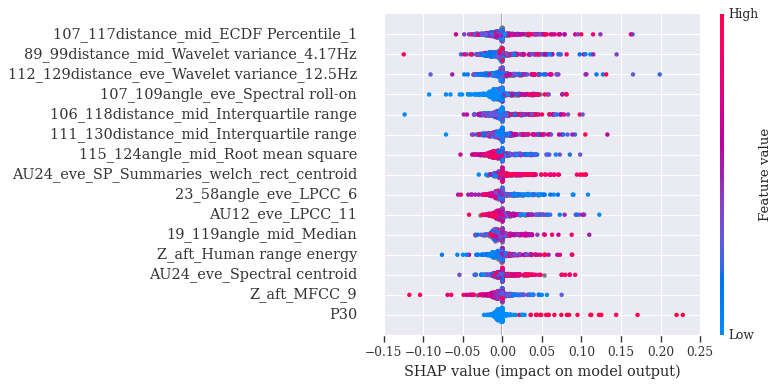

In [129]:
import matplotlib.pyplot
all_shap_values_concat = np.concatenate([sv for sv in all_shap_values])  # Use sv[1], sv[2], etc., for other classes

# Visualize SHAP values for all samples
shap.summary_plot(all_shap_values_concat, X_test_all, max_display=15, plot_size=[10,5], show=False)
matplotlib.pyplot.savefig("shap_summary_knn_smote_nest_predict.pdf",dpi=700) #.png,.pdf will also support here
